## 1. Query a clean Euclid galaxy sample

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astroquery.esa.euclid import Euclid

project_root = Path(r"D:\AST\07_Euclid_Q1_Case_Study")
field_ra, field_dec, search_radius_deg = 267.3807789, 65.4983, 5 / 60

query = f"""
SELECT TOP 2000
    mer.object_id, mer.right_ascension, mer.declination,
    mer.det_quality_flag, mer.spurious_flag, mer.point_like_prob,
    mer.flux_vis_sersic, mer.flux_y_sersic, mer.flux_j_sersic, mer.flux_h_sersic,
    cls.phz_star_prob, cls.phz_gal_prob, cls.phz_qso_prob,
    pz.phz_median
FROM catalogue.mer_catalogue AS mer
INNER JOIN catalogue.phz_classification AS cls ON mer.object_id = cls.object_id
INNER JOIN catalogue.phz_photo_z AS pz ON mer.object_id = pz.object_id
WHERE DISTANCE({field_ra}, {field_dec}, mer.right_ascension, mer.declination) < {search_radius_deg}
    AND mer.vis_det = 1
    AND mer.spurious_flag = 0
    AND mer.det_quality_flag = 0
    AND mer.flux_vis_sersic > 0
    AND mer.flux_y_sersic > 0
    AND mer.flux_j_sersic > 0
    AND mer.flux_h_sersic > 0
    AND cls.phz_gal_prob >= 0.8
"""

job = Euclid.launch_job_async(query, verbose=False)
galaxy_sample = job.get_results()

print("Rows returned:", len(galaxy_sample))
galaxy_sample[:10]

INFO: Query finished. [astroquery.utils.tap.core]
Rows returned: 2000


object_id,right_ascension,declination,det_quality_flag,spurious_flag,point_like_prob,flux_vis_sersic,flux_y_sersic,flux_j_sersic,flux_h_sersic,phz_star_prob,phz_gal_prob,phz_qso_prob,phz_median
int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2674217478654198805,267.42174784897355,65.41988050288667,0,0,1.1305167390673887e-05,8.990766525268555,15.030097961425781,15.421895027160645,18.41611099243164,0.004634540528059006,0.8633173704147339,0.27196842432022095,0.23999999463558197
2674134668654206968,267.41346680240235,65.42069683260364,0,0,0.0022774594835937023,16.100975036621094,39.745140075683594,57.27988815307617,80.2485580444336,0.0023087826557457447,0.9705604910850525,0.013928661122918129,0.3400000035762787
2673815167654209093,267.38151676828727,65.42090936359364,0,0,0.0002767000696621835,0.994939923286438,2.7293148040771484,2.71000337600708,3.383166790008545,0.002725293394178152,0.961893618106842,0.04001729190349579,0.20999999344348907
2674639931654291412,267.463993111479,65.42914126000285,0,0,5.469850748340832e-06,0.1775682419538498,0.4500241279602051,0.7605091333389282,0.7240387201309204,0.02113158442080021,0.816778302192688,0.30728626251220703,1.8700000047683716
2674804832654318035,267.4804832290068,65.43180356153943,0,0,0.002088569337502122,1.776625156402588,3.2856733798980713,3.247898817062378,3.6174163818359375,0.0044657508842647076,0.9678397178649902,0.016677141189575195,0.7200000286102295
2675030103654389577,267.5030103327964,65.43895773873426,0,0,0.0004937322228215635,0.24148303270339966,0.6358470320701599,0.7689628601074219,0.7880859375,0.009189638309180737,0.8639304041862488,0.16625294089317322,1.659999966621399
2672729235654392832,267.27292357937415,65.43928320414444,0,0,0.5887095332145691,0.33627593517303467,0.740397572517395,0.6994876265525818,0.7679758071899414,0.010371671989560127,0.8396148085594177,0.24435767531394958,0.5400000214576721
2673310436654450883,267.33104361565285,65.44508834482158,0,0,0.0006812086212448776,0.10912415385246277,0.23860818147659302,0.24802087247371674,0.26608091592788696,0.00572993652895093,0.8455272316932678,0.20482997596263885,2.200000047683716
2672364502654463277,267.236450264563,65.44632776658442,0,0,0.0,0.18714012205600739,0.4741349220275879,0.529242217540741,0.5024378895759583,0.013702897354960442,0.868281900882721,0.15416748821735382,1.2699999809265137


## 2. Convert catalogue fluxes into AB colours

In [2]:
galaxy_df = galaxy_sample.to_pandas()

flux_columns = ["flux_vis_sersic", "flux_y_sersic", "flux_j_sersic", "flux_h_sersic"]
numeric_columns = flux_columns + ["phz_median", "phz_star_prob", "phz_gal_prob", "phz_qso_prob"]

for column in numeric_columns:
    galaxy_df[column] = pd.to_numeric(galaxy_df[column], errors="coerce")

galaxy_df = galaxy_df.dropna(subset=numeric_columns).copy()
galaxy_df = galaxy_df[(galaxy_df["phz_median"] > 0) & (galaxy_df["phz_median"] < 4)].copy()

for band in ["vis", "y", "j", "h"]:
    galaxy_df[f"mag_{band}"] = 23.9 - 2.5 * np.log10(galaxy_df[f"flux_{band}_sersic"])

galaxy_df["vis_minus_h"] = galaxy_df["mag_vis"] - galaxy_df["mag_h"]
galaxy_df["y_minus_j"] = galaxy_df["mag_y"] - galaxy_df["mag_j"]
galaxy_df["j_minus_h"] = galaxy_df["mag_j"] - galaxy_df["mag_h"]

print("Usable galaxies:", len(galaxy_df))
galaxy_df[["phz_median", "mag_vis", "mag_h", "vis_minus_h", "y_minus_j", "j_minus_h"]].describe()

Usable galaxies: 1944


,phz_median,mag_vis,mag_h,vis_minus_h,y_minus_j,j_minus_h
count,1944.000000,1944.000000,1944.000000,1944.000000,1944.000000,1944.000000
mean,1.351445,24.908685,23.748285,1.160400,0.186643,0.151296
std,0.933046,1.353511,1.560298,0.664769,0.470419,0.427865
min,0.050000,18.381178,17.116656,-3.350615,-3.414296,-2.769159
25%,0.660000,24.303665,23.011042,0.777414,0.001958,-0.016875
50%,1.040000,25.259166,24.068557,1.137981,0.194590,0.150727
75%,1.790000,25.898927,24.781884,1.524138,0.385969,0.318148
max,3.990000,32.941035,29.569408,8.314728,2.744448,4.465868


## 3. Measure the colour–redshift relation

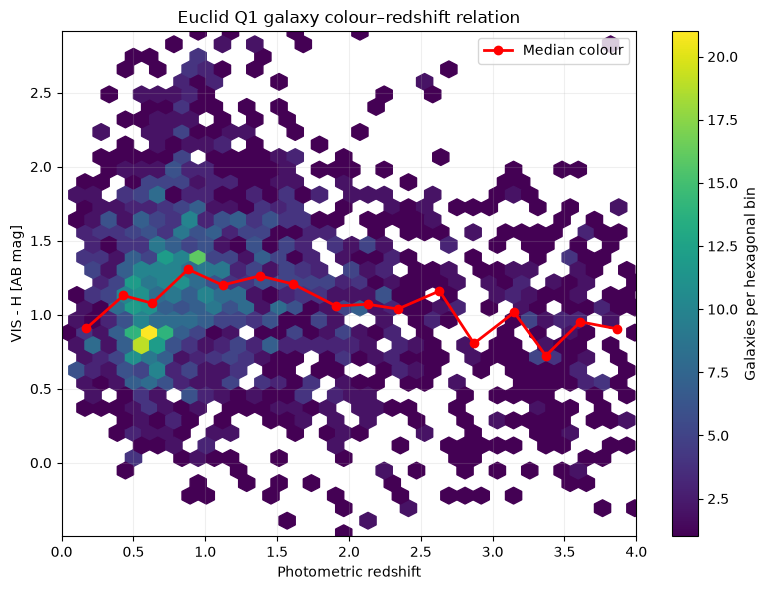

Galaxies plotted: 1904
Saved figure: D:\AST\07_Euclid_Q1_Case_Study\outputs\figures\euclid_vis_h_vs_photoz.png
Saved sample: D:\AST\07_Euclid_Q1_Case_Study\outputs\tables\euclid_clean_galaxy_sample.csv
Saved binned statistics: D:\AST\07_Euclid_Q1_Case_Study\outputs\tables\euclid_vis_h_photoz_binned.csv


In [3]:
color_low, color_high = galaxy_df["vis_minus_h"].quantile([0.01, 0.99])
plot_df = galaxy_df[galaxy_df["vis_minus_h"].between(color_low, color_high)].copy()

redshift_bins = np.linspace(0, 4, 17)
plot_df["redshift_bin"] = pd.cut(plot_df["phz_median"], bins=redshift_bins)

binned_stats = plot_df.groupby("redshift_bin", observed=True).agg(
    median_redshift=("phz_median", "median"),
    median_color=("vis_minus_h", "median"),
    galaxy_count=("object_id", "size"),
).reset_index()

figure_output_path = project_root / "outputs" / "figures" / "euclid_vis_h_vs_photoz.png"
sample_output_path = project_root / "outputs" / "tables" / "euclid_clean_galaxy_sample.csv"
statistics_output_path = project_root / "outputs" / "tables" / "euclid_vis_h_photoz_binned.csv"

fig, ax = plt.subplots(figsize=(8, 6))
density = ax.hexbin(plot_df["phz_median"], plot_df["vis_minus_h"], gridsize=35, mincnt=1, cmap="viridis")
ax.plot(binned_stats["median_redshift"], binned_stats["median_color"], color="red", marker="o", linewidth=2, label="Median colour")
ax.set(xlim=(0, 4), ylim=(color_low, color_high), xlabel="Photometric redshift", ylabel="VIS - H [AB mag]", title="Euclid Q1 galaxy colour–redshift relation")
ax.grid(alpha=0.2)
ax.legend()
fig.colorbar(density, ax=ax, label="Galaxies per hexagonal bin")

fig.tight_layout()
fig.savefig(figure_output_path, dpi=300, bbox_inches="tight")
plt.show()

galaxy_df.to_csv(sample_output_path, index=False)
binned_stats.to_csv(statistics_output_path, index=False)

print("Galaxies plotted:", len(plot_df))
print("Saved figure:", figure_output_path)
print("Saved sample:", sample_output_path)
print("Saved binned statistics:", statistics_output_path)